<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs. 

In [9]:
# Import Libraries (pandas, numpy, matplotlib)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ....
# ...
# ...


### Data

We will use retail data for time-series modeling. 

Link to the dataset:
 https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.



##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

_________________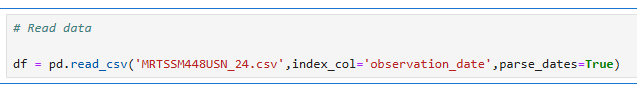

In [10]:
# Read data
df = pd.read_csv('MRTSSM448USN_24-1.csv',index_col='observation_date',parse_dates=True)

In [11]:
#pd.read_csv

In [12]:
# Print the first few rows of data
df.head(5)
# ...

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


_______________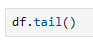

In [13]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [14]:
# Set name of column as 'Sales'. Use - df.columns 
print(df.head())
# ...


                  MRTSSM448USN
observation_date              
1992-01-01                6938
1992-02-01                7524
1992-03-01                8475
1992-04-01                9401
1992-05-01                9558


Plot your data - Year vs Sales

hint: use df.plot  and plt.show()

____________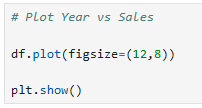

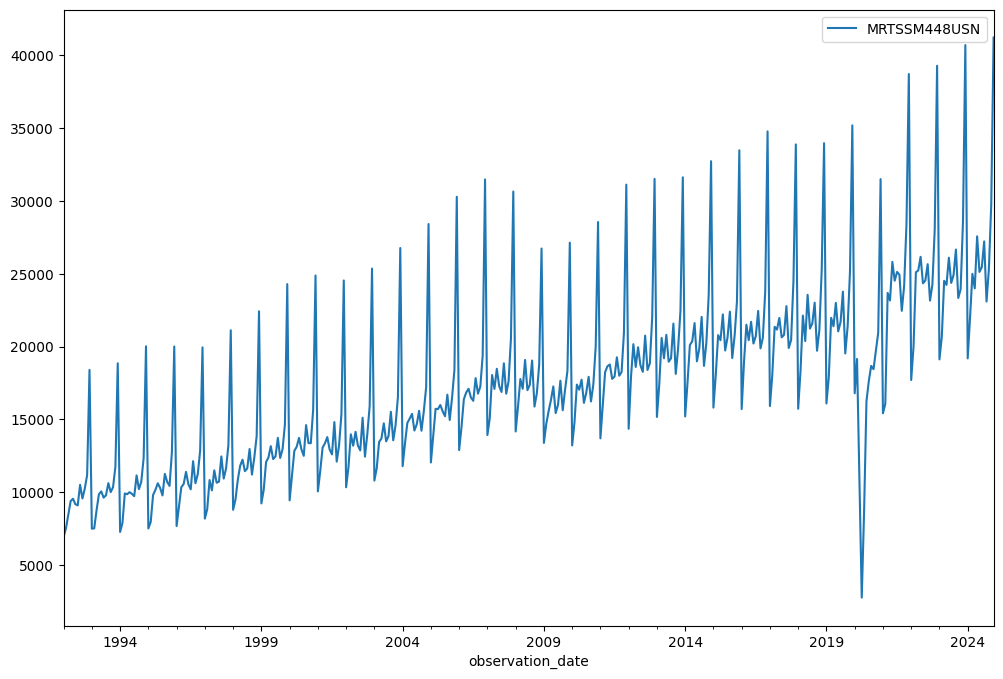

In [15]:
df.plot(figsize=(12,8))
plt.show()

### Train Test Split 

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

______________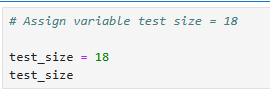

In [16]:
test_size = 18
test_size

18

__________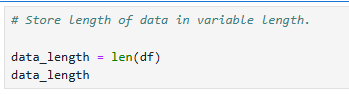

In [17]:
data_length = len(df)
data_length

396

__________________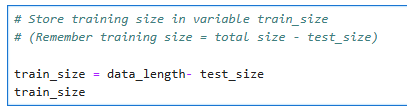

In [18]:
train_size = data_length - test_size
train_size

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe.

____________________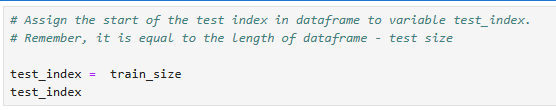

In [19]:
test_index = train_size
test_index

378

Next, we will separate train and test datasets.

_________________________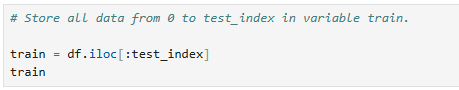

In [20]:
train = df.iloc[:test_index]
train

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2023-02-01,20666
2023-03-01,24510
2023-04-01,24232


In [21]:
# Store everything from test_index to the last sample in the test variable 
# Hint - Use df.iloc
test = df.iloc[test_index:]
# ...
# ...


In [22]:
print(test)

                  MRTSSM448USN
observation_date              
2023-07-01               24911
2023-08-01               26657
2023-09-01               23332
2023-10-01               23933
2023-11-01               28580
2023-12-01               40684
2024-01-01               19188
2024-02-01               22005
2024-03-01               24986
2024-04-01               23993
2024-05-01               27562
2024-06-01               25121
2024-07-01               25453
2024-08-01               27215
2024-09-01               23088
2024-10-01               25318
2024-11-01               29762
2024-12-01               41199


In [23]:
# Print the size of the train data

# ...
print(len(train))
print(len(test))
# Print the size of the test data

# ...


378
18


### In Neural Networks, we need to Scale Data between 0-1

___________________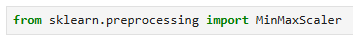

In [28]:
from sklearn.preprocessing import MinMaxScaler

_______________________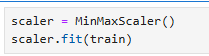

In [29]:
scaler = MinMaxScaler()
scaler.fit(train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


__________________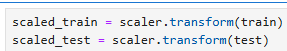

In [30]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [31]:
# Check if the data has been scaled properly
# Print max and min for train and test
print("Train Min:", scaled_train.min())
print("Train Max:", scaled_train.max())

print("Test Min:", scaled_test.min())
print("Test Max:", scaled_test.max())
# ...
# ...
# ...
# ...

Train Min: 0.0
Train Max: 1.0
Test Min: 0.44980403979499545
Test Max: 1.0530599939704552


## Time Series Generator

This class takes in a sequence of data points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

### We will use 12 months as input and then predict the next month out


_____________________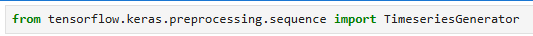

In [32]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [33]:
#TimeseriesGenerator?

_________________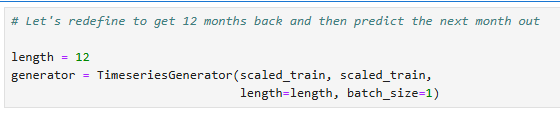

In [34]:
# Let's redefine to get 12 months back and then predict the next month out
length = 12
generator = TimeseriesGenerator(scaled_train, scaled_train,
length=length, batch_size=1)

_______________________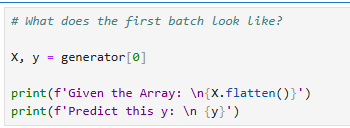

In [35]:
# What does the first batch look Like?
X, y = generator [0]
print (f'Given the Array: In{X.flatten()}')
print(f'Predict this y: In {y}')

Given the Array: In[0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: In [[0.12952558]]


### Create the Model

__________________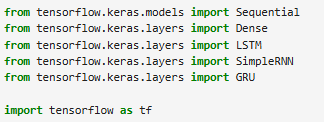

In [36]:

from tensorflow.keras.models import Sequential



from tensorflow.keras.layers import Dense



from tensorflow.keras.layers import LSTM



from tensorflow.keras.layers import SimpleRNN



from tensorflow.keras.layers import GRU



import tensorflow as tf



________________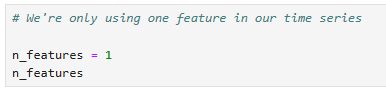

In [37]:
n_features = 1
n_features

1

## Define your own models. 

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [38]:
# Your code to create your own model
# use input_shape=(length, n_features)
# use model.add(Dense(1)) because it is the regression task
model = tf.keras.Sequential()

model.add(tf.keras.layers.SimpleRNN(100, activation='relu', input_shape=(length, n_features)))
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')
# .....
# .....
# .....


2026-02-26 12:08:37.071396: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-26 12:08:37.071508: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-26 12:08:37.072118: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-26 12:08:37.072350: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-26 12:08:37.072897: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/envs/tf310/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential mo

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,301 (40.24 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

_____________________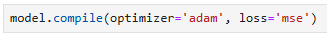

In [40]:
model.compile(optimizer='adam', loss='mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches. 

Review the video on the Week-6 page for more info on this.

____________________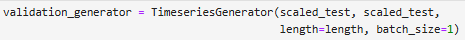

In [41]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test,
length=length, batch_size=1)

___________________

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

 
LAST_DIGIT_IN_YOUR_SID = 9

early_stop = EarlyStopping(monitor='val_loss', patience=LAST_DIGIT_IN_YOUR_SID)


_____________________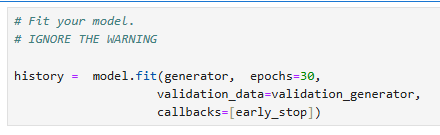

In [44]:
history = model.fit(
    generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Epoch 1/30


2026-02-26 12:08:57.163768: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


366/366 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - loss: 0.0183 - val_loss: 0.0276
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - loss: 0.0074 - val_loss: 0.0045
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 0.0043 - val_loss: 0.0071
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.0047 - val_loss: 0.0017
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.0029 - val_loss: 9.9952e-04
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.0023 - val_loss: 0.0031
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 0.0022 - val_loss: 3.8659e-04
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.0038 - val_loss: 0.0064
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - loss: 0.0023 - val_loss: 5.8651e-04
Epoch 12/30
366/366 ━━━━━━━━━

_____________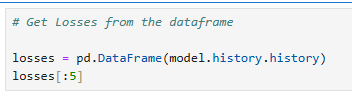

In [45]:
# Get Losses from the dataframe
losses = pd.DataFrame(model.history.history)
losses [:5]

,loss,val_loss
0,0.018336,0.027575
1,0.007403,0.004485
2,0.004337,0.007125
3,0.004734,0.001697
4,0.002885,0.001000


In [ ]:
# the values may be different


___________________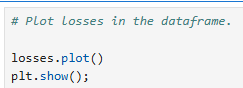

<function matplotlib.pyplot.show(close=None, block=None)>

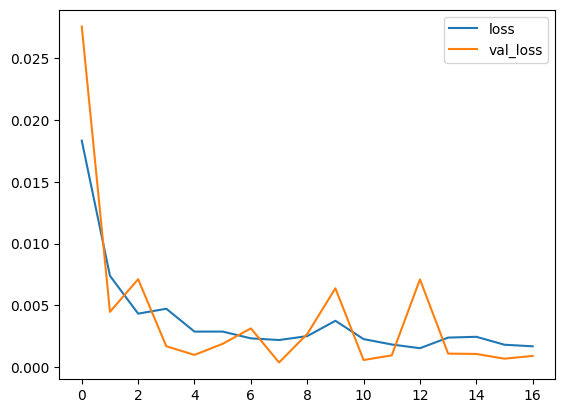

In [46]:
losses.plot()
plt.show

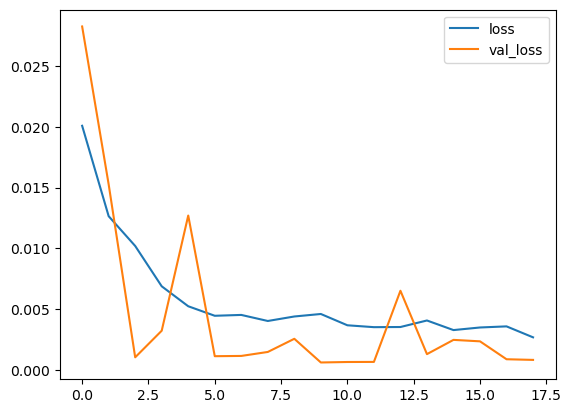

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

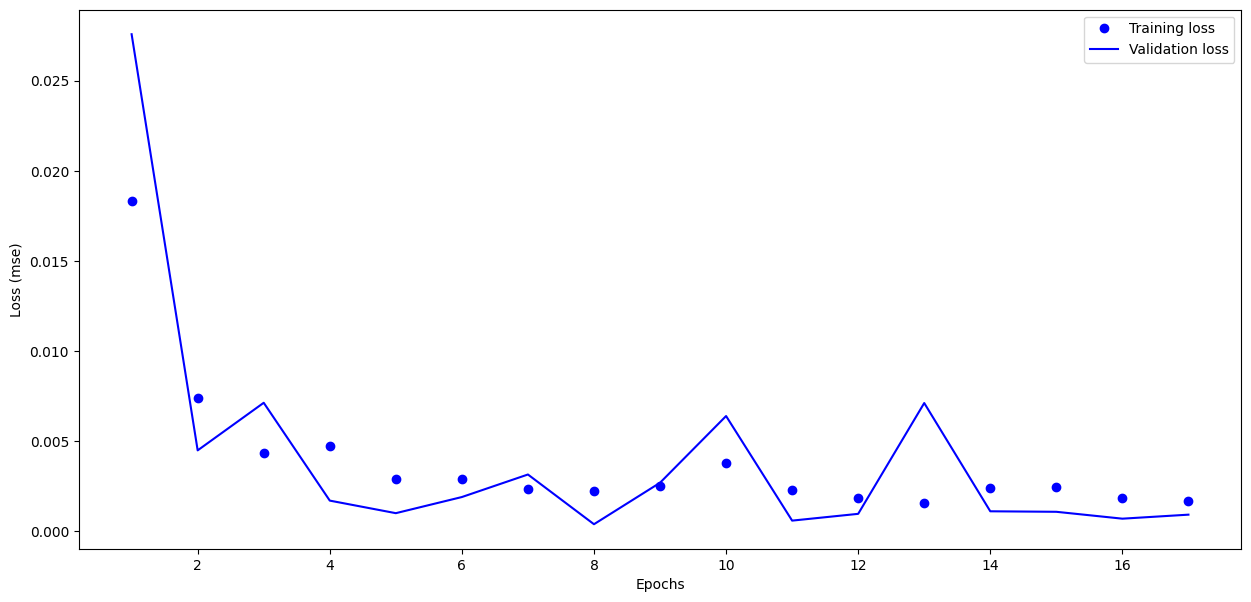

In [47]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

____________________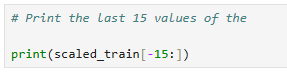

In [49]:
print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


____________________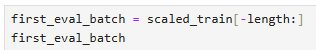

In [50]:
first_eval_batch = scaled_train[-length:]
first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [51]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

___________________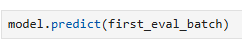

In [52]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


array([[0.61859596]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step


array([[0.63285655]], dtype=float32)

_________________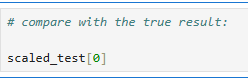

In [54]:
scaled_test[0]

array([0.60665442])

array([0.60665442])

#### Try predicting the series!

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [55]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

____________________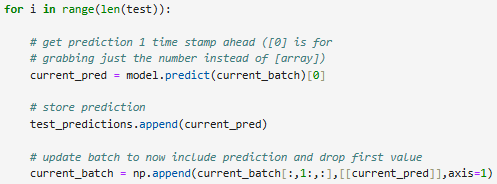

In [57]:
for i in range(len(test)):
    # get prediction 1 time stamp ahead ([0] is for
    # grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    # store prediction
    test_predictions.append (current_pred)
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


______________________

In [58]:
test_predictions

[array([0.61859596], dtype=float32),
 array([0.60306615], dtype=float32),
 array([0.5439121], dtype=float32),
 array([0.58848506], dtype=float32),
 array([0.6704916], dtype=float32),
 array([0.954278], dtype=float32),
 array([0.48519802], dtype=float32),
 array([0.51630825], dtype=float32),
 array([0.58387774], dtype=float32),
 array([0.5489102], dtype=float32),
 array([0.6126218], dtype=float32),
 array([0.5811319], dtype=float32),
 array([0.59873927], dtype=float32),
 array([0.5832926], dtype=float32),
 array([0.53023857], dtype=float32),
 array([0.57563096], dtype=float32),
 array([0.6486499], dtype=float32),
 array([0.9222904], dtype=float32)]

[array([0.63285655], dtype=float32),
 array([0.655915], dtype=float32),
 array([0.60953766], dtype=float32),
 array([0.63251466], dtype=float32),
 array([0.7280531], dtype=float32),
 array([1.0275557], dtype=float32),
 array([0.494833], dtype=float32),
 array([0.53379714], dtype=float32),
 array([0.6105526], dtype=float32),
 array([0.62500674], dtype=float32),
 array([0.66780484], dtype=float32),
 array([0.6402486], dtype=float32),
 array([0.66947997], dtype=float32),
 array([0.68683314], dtype=float32),
 array([0.65377283], dtype=float32),
 array([0.6738984], dtype=float32),
 array([0.7653416], dtype=float32),
 array([1.0579401], dtype=float32)]

### Inverse Transformations and Compare

_________________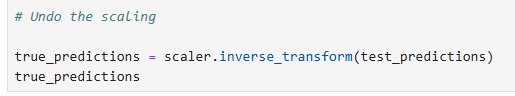

In [59]:
# Undo the scaling
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[25346.71071064],
       [24780.07448274],
       [22621.72125655],
       [24248.05446166],
       [27240.22614062],
       [37594.74110317],
       [20479.42018986],
       [21614.53904635],
       [24079.94718295],
       [22804.08648914],
       [25128.73104048],
       [23979.75874192],
       [24622.19961298],
       [24058.59722364],
       [22122.81465918],
       [23779.04694146],
       [26443.28785592],
       [36427.60926908]])

array([[25867.03686076],
       [26708.37140393],
       [25016.20063967],
       [25854.56223851],
       [29340.47320271],
       [40268.42497611],
       [20830.97139931],
       [22252.6564256 ],
       [25053.23304337],
       [25580.6207518 ],
       [27142.1950959 ],
       [26136.75054663],
       [27203.31552541],
       [27836.48089719],
       [26630.20928335],
       [27364.5308798 ],
       [30701.01822633],
       [41377.06135786]])

_____________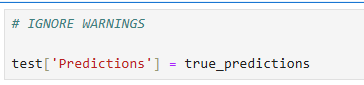

In [61]:
test['Predictions'] = true_predictions

/var/folders/dz/b0frrhl544q2z7kjm0yc44x40000gn/T/ipykernel_27346/4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


C:\Users\vital\AppData\Local\Temp\ipykernel_18288\3095654106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


### Check and plot predictions

In [62]:
# Print the test variable
print(test)
# ...


                  MRTSSM448USN   Predictions
observation_date                            
2023-07-01               24911  25346.710711
2023-08-01               26657  24780.074483
2023-09-01               23332  22621.721257
2023-10-01               23933  24248.054462
2023-11-01               28580  27240.226141
2023-12-01               40684  37594.741103
2024-01-01               19188  20479.420190
2024-02-01               22005  21614.539046
2024-03-01               24986  24079.947183
2024-04-01               23993  22804.086489
2024-05-01               27562  25128.731040
2024-06-01               25121  23979.758742
2024-07-01               25453  24622.199613
2024-08-01               27215  24058.597224
2024-09-01               23088  22122.814659
2024-10-01               25318  23779.046941
2024-11-01               29762  26443.287856
2024-12-01               41199  36427.609269


,Sales,Predictions
observation_date,,
2023-07-01,24911,25867.036861
2023-08-01,26657,26708.371404
2023-09-01,23332,25016.200640
2023-10-01,23933,25854.562239
2023-11-01,28580,29340.473203
2023-12-01,40684,40268.424976
2024-01-01,19188,20830.971399
2024-02-01,22005,22252.656426
2024-03-01,24986,25053.233043


_______________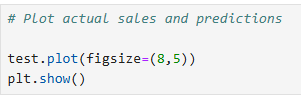

<function matplotlib.pyplot.show(close=None, block=None)>

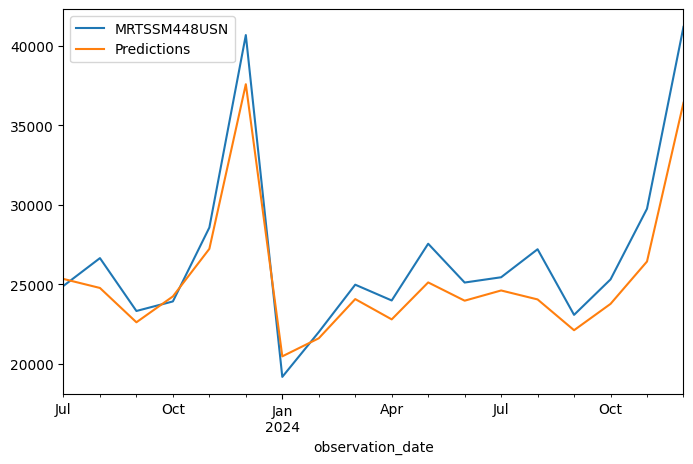

In [63]:
test.plot(figsize = (8,5))
plt.show

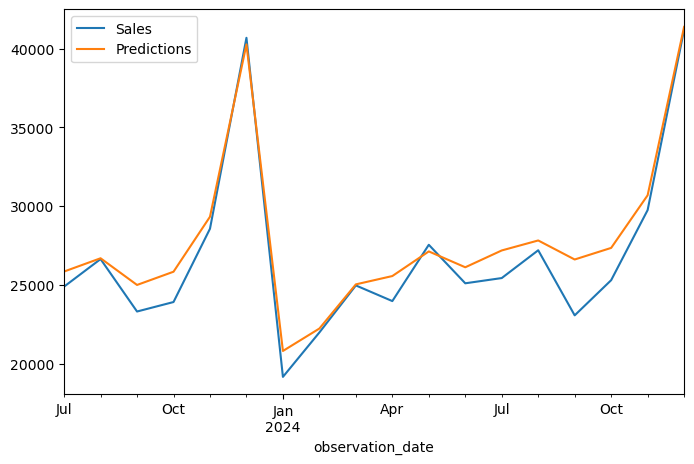

### Retrain and Forecasting

_________________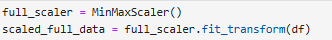

In [65]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

______________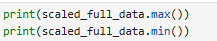

In [66]:
print(scaled_full_data.max())
print(scaled_full_data.min())

1.0
0.0


1.0
0.0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [67]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data, 
                                scaled_full_data, length=length, batch_size=1)

In [68]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

model = Sequential([
    Input(shape=(length, n_features)),
    SimpleRNN(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])
# ...
# ...
# ...


C:\Users\vital\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [69]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# your code to compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
# ...

In [71]:
from tensorflow.keras.callbacks import EarlyStopping

LAST_DIGIT_IN_YOUR_SID = 9

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=LAST_DIGIT_IN_YOUR_SID,
    restore_best_weights=True
)

____________________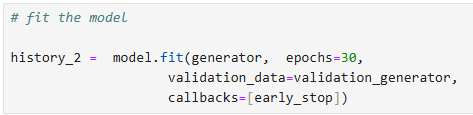

In [72]:
# fit the model

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - loss: 0.0239 - mae: 0.0971 - val_loss: 0.0242 - val_mae: 0.1192
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - loss: 0.0101 - mae: 0.0695 - val_loss: 0.0109 - val_mae: 0.0921
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - loss: 0.0187 - mae: 0.0950 - val_loss: 0.0549 - val_mae: 0.1980
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - loss: 0.0183 - mae: 0.1042 - val_loss: 0.0430 - val_mae: 0.1471
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - loss: 0.0151 - mae: 0.0917 - val_loss: 0.0165 - val_mae: 0.0739
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - loss: 0.0122 - mae: 0.0803 - val_loss: 0.0223 - val_mae: 0.1178
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - loss: 0.0206 - mae: 0.0983 - val_loss: 0.1530 - val_mae: 0.3633
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - loss: 0.0169 - mae: 0.0995 - val_loss: 0.0123 - val_mae: 0.0863
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

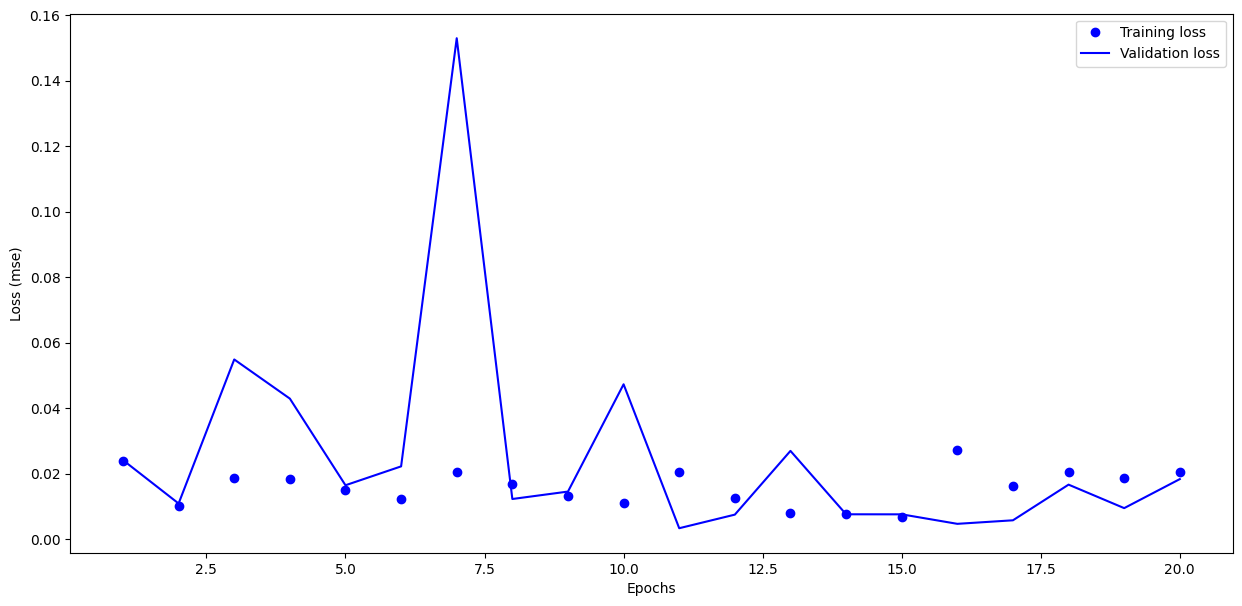

In [73]:
# print Loss for the neural network training process

history_dict = history_2.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

In [215]:
# You can use the code created above to type the next cell code

_________________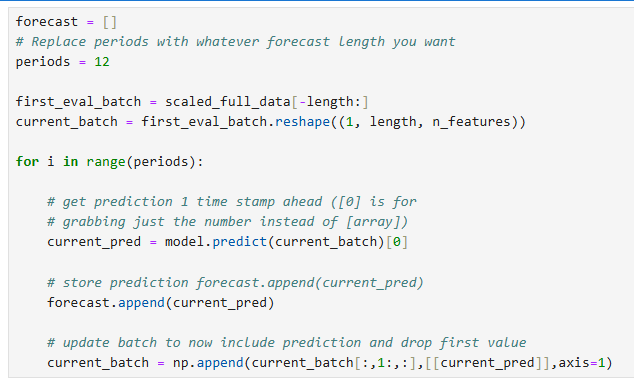

In [79]:
forecast = []
# Replace periods with whatever forecast Length you want
periods = 12
first_eval_batch = scaled_full_data[-length: ]
current_batch = first_eval_batch.reshape((1, length, n_features))
for i in range(periods) :
    # get prediction 1 time stamp ahead ([0] is for
    # grabbing just the number instead of [array])
    current_pred = model.predict(current_batch) [0]
    # store prediction forecast.append(current_pred)
    forecast.append (current_pred)
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


______________________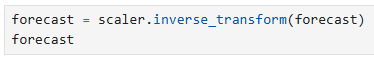

In [80]:
forecast = scaler.inverse_transform(forecast)
forecast

array([[21637.30697179],
       [21472.67066538],
       [22932.4428708 ],
       [21991.22000825],
       [23422.65028948],
       [22349.00635403],
       [23437.90429932],
       [23943.88332897],
       [19953.70054895],
       [20905.59077936],
       [26401.82104588],
       [37359.11514902]])

array([[18620.61448288],
       [20206.91406763],
       [22167.73939276],
       [21757.40348327],
       [23828.92585731],
       [22448.01823115],
       [22479.73978627],
       [23555.70857722],
       [21352.45454019],
       [22294.99097872],
       [25707.46347636],
       [37294.23667431]])

### Creating new timestamp index with pandas.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 4 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [81]:
df

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


##### Forecast for next 12 months

__________________

In [84]:
forecast_index = pd.date_range(start='2025-01-01', periods=periods, freq='MS')

__________________________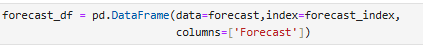

In [85]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,
columns=['Forecast' ])

________________________

In [86]:
forecast_df

,Forecast
2025-01-01,21637.306972
2025-02-01,21472.670665
2025-03-01,22932.442871
2025-04-01,21991.220008
2025-05-01,23422.650289
2025-06-01,22349.006354
2025-07-01,23437.904299
2025-08-01,23943.883329
2025-09-01,19953.700549
2025-10-01,20905.590779


,Forecast
2025-01-01,18620.614483
2025-02-01,20206.914068
2025-03-01,22167.739393
2025-04-01,21757.403483
2025-05-01,23828.925857
2025-06-01,22448.018231
2025-07-01,22479.739786
2025-08-01,23555.708577
2025-09-01,21352.454540
2025-10-01,22294.990979


__________________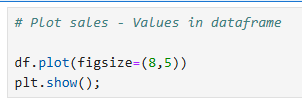

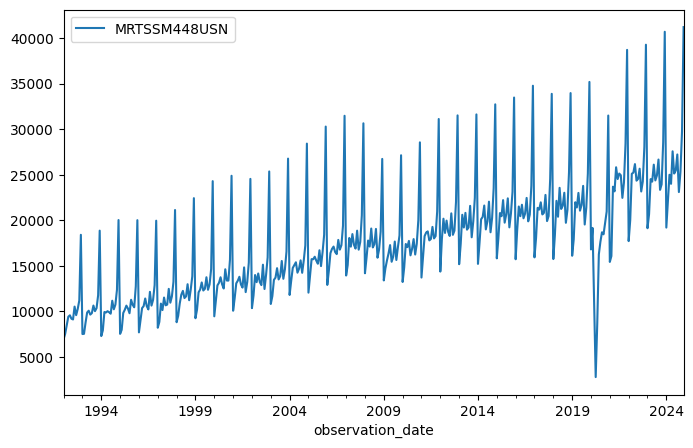

In [87]:
# Plot sales - Values in dataframe
df.plot(figsize=(8,5))
plt.show();

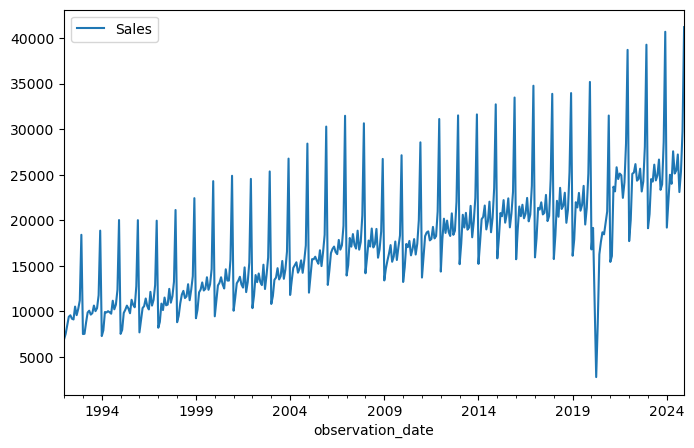

____________________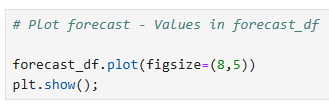

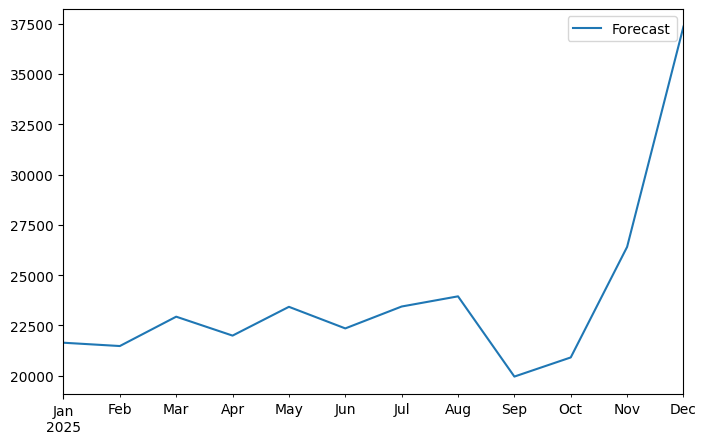

In [88]:
# Plot forecast - Values in forecast_af
forecast_df.plot(figsize=(8,5))
plt.show();

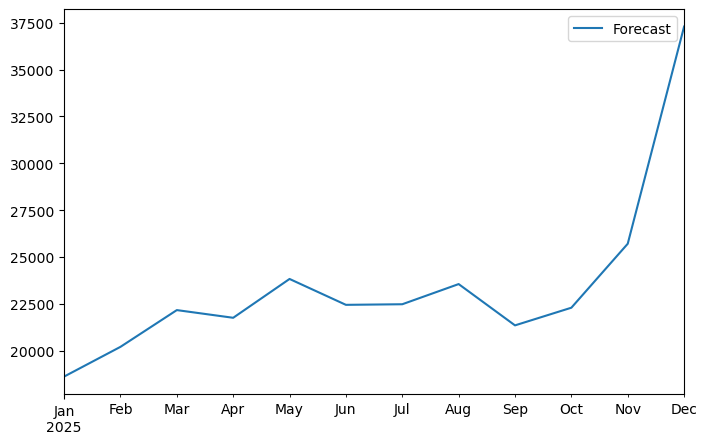

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

________________________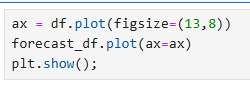

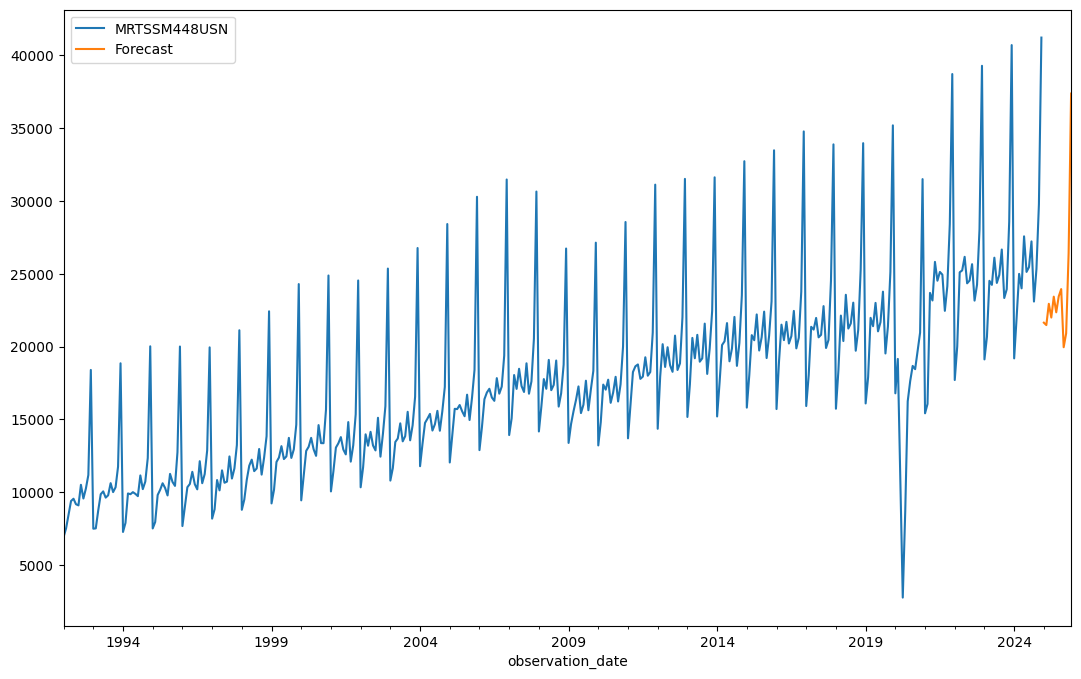

In [89]:
ax = df.plot(figsize=(13,8))
forecast_df.plot (ax=ax)
plt.show();

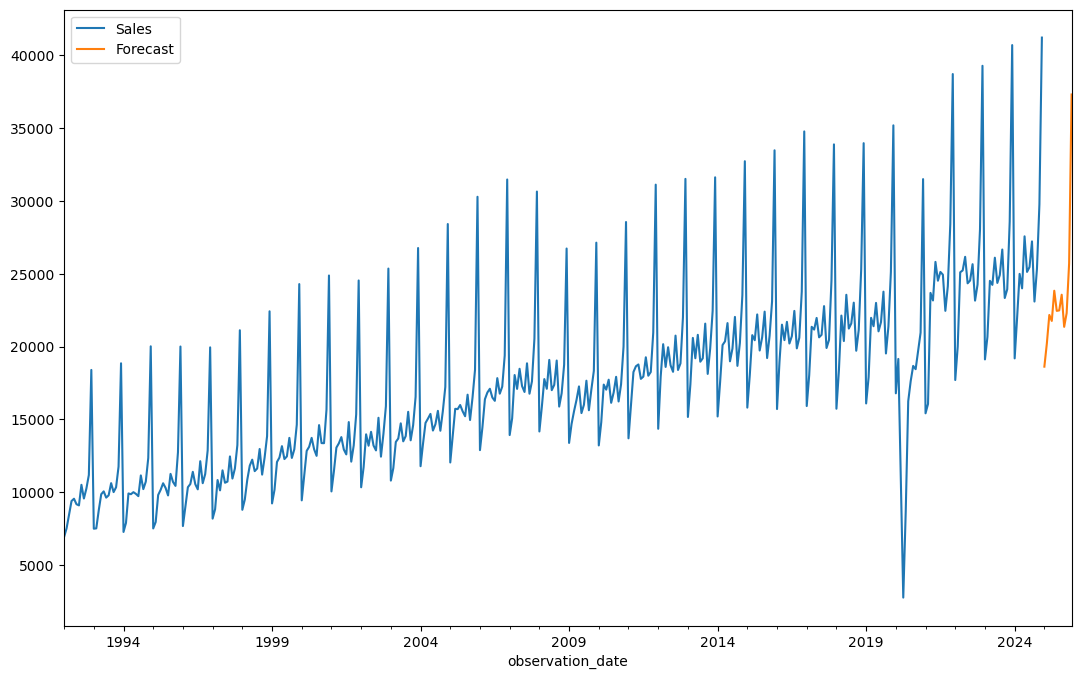

_______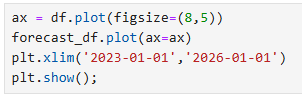

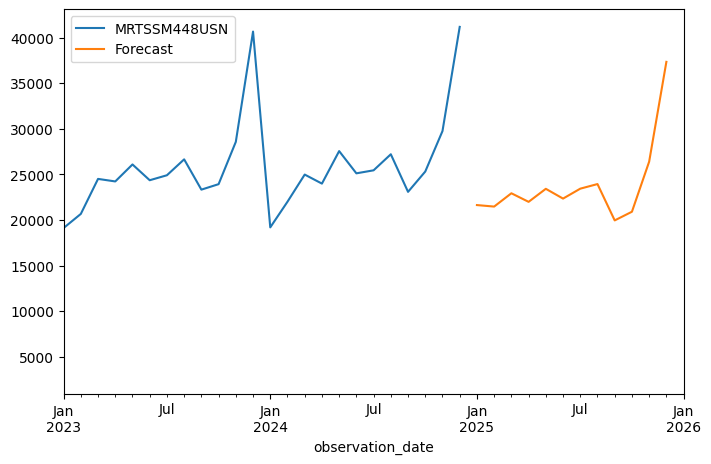

In [90]:
ax = df.plot(figsize=(8,5))
forecast_df.plot(ax=ax)
plt.xlim('2023-01-01','2026-01-01')
plt.show();

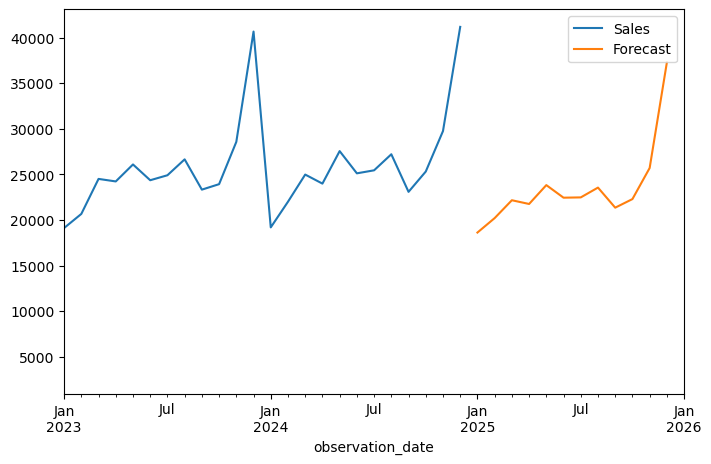

### Checking Forecast for last 12 months

_______________________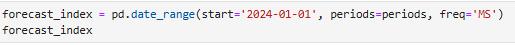

In [92]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

________________________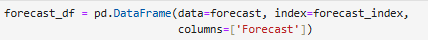

In [95]:
forecast_df = pd.DataFrame(
    data=forecast,
    index=forecast_index,
    columns=['Forecast']
)

___________________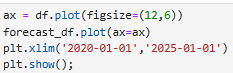

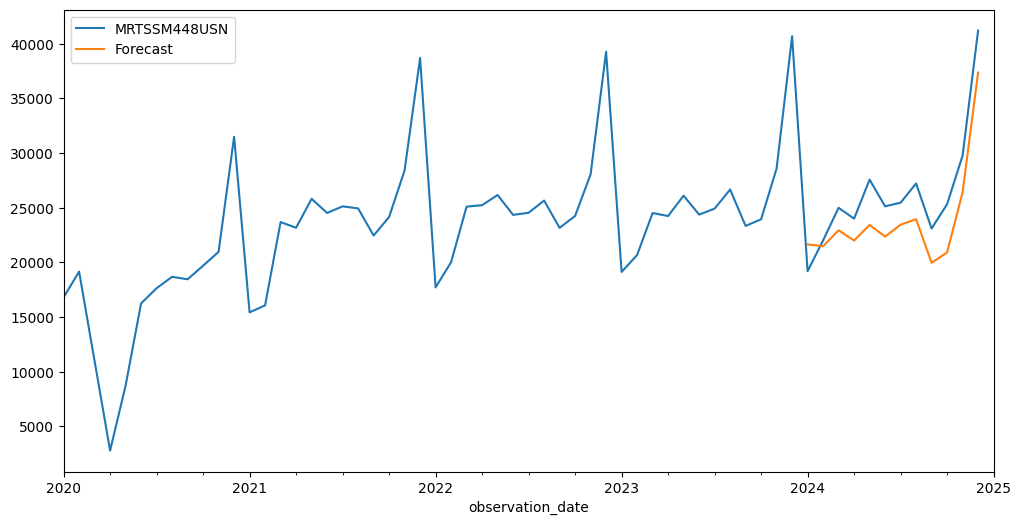

In [96]:
ax = df.plot(figsize=(12,6))
forecast_df.plot (ax=ax)
plt.xlim('2020-01-01','2025-01-01')
plt.show();

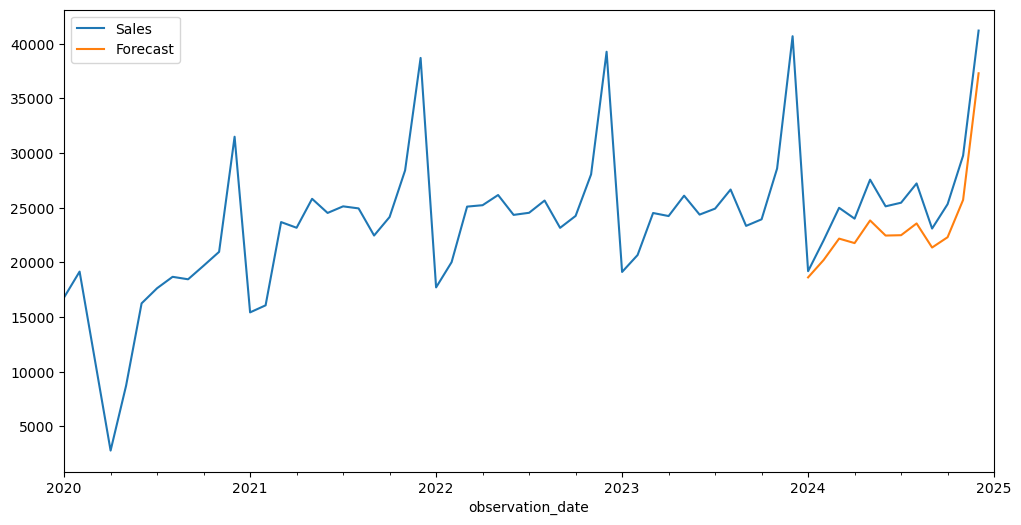

In [97]:
import numpy as np
optimal_epoch = np.argmin(losses['val_loss']) + 1
print("Optimal number of epochs:", optimal_epoch)

Optimal number of epochs: 8


<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Record the 2nd model's code & plot the summary()

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model. 

### 5. Record the plot of the Checking Forecast for the last 12 months (last graph).

### Try the same example with a LSTM and/or GRU! (Optional)
Hint: Use LSTM instead of SimpleRNN!